In [10]:
import sys
from pathlib import Path

class ImportMyModules:

    def __init__(self) -> None:
        self.cwd = Path.cwd().resolve()

    def _get_repo_root(self, folder: str) -> Path:
        return next(
            parent for parent in [self.cwd, *self.cwd.parents]
            if (parent / "lib" / "peregrin" / folder).exists()
        )

    def insert_path(self, folder: str) -> None:
        repo_root = self._get_repo_root("src")

        package_root = repo_root / "lib" / "peregrin"
        print(f"Adding {package_root} to sys.path")
        sys.path.insert(0, str(package_root))

importer = ImportMyModules()
importer.insert_path("src")
importer.insert_path("data")

from importlib import reload

Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path


In [11]:
import src.data_handler.data_loader as load_module
reload(load_module)
load_data = load_module.load_data

In [12]:
# data = load_data(r"./dummy_data/testing_0")

# data = load_data(
#     r"./dummy_data/tree",
#     colnames = {
#         'id': 'track_id',
#         't': 'time_point',
#         'x': 'x_coordinate',
#         'y': 'y_coordinate'
#     },
# )

data = load_data(
    r"../data/memory_ctr_BC39.csv"
)

In [13]:
data.metadata.write(spatialunits='um', timeunits='s')
data.metadata.get()

{'timeunits': 's',
 'spatialunits': 'μm',
 'nframes': 60,
 'timeinterval': 60.0,
 'columns': ['LABEL',
  'ID',
  'TRACK_ID',
  'QUALITY',
  'POSITION_X',
  'POSITION_Y',
  'POSITION_Z',
  'POSITION_T',
  'FRAME',
  'RADIUS',
  'VISIBILITY',
  'MANUAL_SPOT_COLOR',
  'MEAN_INTENSITY_CH1',
  'MEDIAN_INTENSITY_CH1',
  'MIN_INTENSITY_CH1',
  'MAX_INTENSITY_CH1',
  'TOTAL_INTENSITY_CH1',
  'STD_INTENSITY_CH1',
  'CONTRAST_CH1',
  'SNR_CH1']}

In [14]:
import src.object_interface as object_module
reload(object_module)
create_object = object_module.create_object

data_object = create_object(data)

In [15]:
data_object.compute_tracks()

set,track_uid,speed_min,speed_max,speed_mean,speed_sd,speed_median,track_length,x_location,y_location,max_distance_reached,track_start_frame,track_end_frame,mean_straight_line_speed,forward_progression_linearity,direction_mean,direction_var,mean_directional_change,mean_directional_change_rate,track_points,track_displacement,straightness_ratio,track_id
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64
"""memory_ctr_BC39.csv""",0,0.020141,0.229515,0.106979,0.071081,0.095415,192.562995,1094.830067,681.355184,46.094352,0,30,0.012241,0.118236,2.255481,0.871357,80.382617,0.043216,31,22.767964,0.118236,0.0
"""memory_ctr_BC39.csv""",1,0.143331,0.267316,0.184903,0.034672,0.180029,122.036003,76.369174,698.405614,93.985338,0,11,0.130535,0.705966,0.394393,0.237321,24.247918,0.033678,12,93.985338,0.770144,1.0
"""memory_ctr_BC39.csv""",2,0.047809,0.237677,0.13547,0.052644,0.139528,162.563682,791.613574,693.86715,33.321433,0,20,0.019803,0.153487,1.276848,0.793589,64.584291,0.051257,21,24.951444,0.153487,2.0
"""memory_ctr_BC39.csv""",3,0.043922,0.198376,0.115091,0.0467,0.114572,131.203777,1128.342607,691.630295,44.529236,0,19,0.037108,0.32242,-0.042556,0.584931,45.691377,0.038076,20,44.529236,0.33939,3.0
"""memory_ctr_BC39.csv""",4,0.085788,0.25359,0.159677,0.044352,0.152967,114.967656,1023.997629,685.661742,14.492307,0,12,0.017303,0.108365,-2.161114,0.915094,116.581543,0.149464,13,13.496688,0.117396,4.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""memory_ctr_BC39.csv""",909,0.2896,0.2896,0.2896,null,0.2896,17.376004,35.146865,235.455194,17.376004,0,1,0.1448,0.5,2.019024,0.0,null,null,2,17.376004,1.0,909.0
"""memory_ctr_BC39.csv""",910,0.024606,0.099504,0.053673,0.040164,0.036909,9.661169,1.275272,205.253725,5.134973,0,3,0.021396,0.39863,-1.047349,0.430236,60.652062,0.252717,4,5.134973,0.531506,910.0
"""memory_ctr_BC39.csv""",911,0.10363,0.10363,0.10363,null,0.10363,6.217821,597.518266,306.708421,6.217821,0,1,0.051815,0.5,2.757143,0.0,null,null,2,6.217821,1.0,911.0


['set'] peregrin_ql {}
['memory_ctr_BC39.csv']
colors: {'memory_ctr_BC39.csv': '#093190ff'}
a: 5.526011239965953, b: 485.8069743949876
['set'] peregrin_ql {}
['memory_ctr_BC39.csv']
colors: {'memory_ctr_BC39.csv': '#093190ff'}
a: 1.1488649010048286, b: 0.2791375864899427


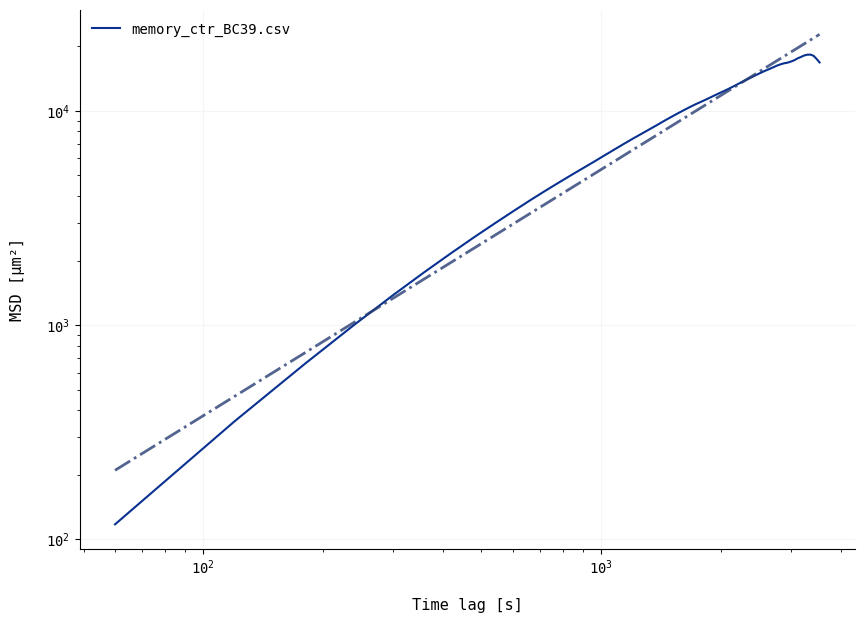

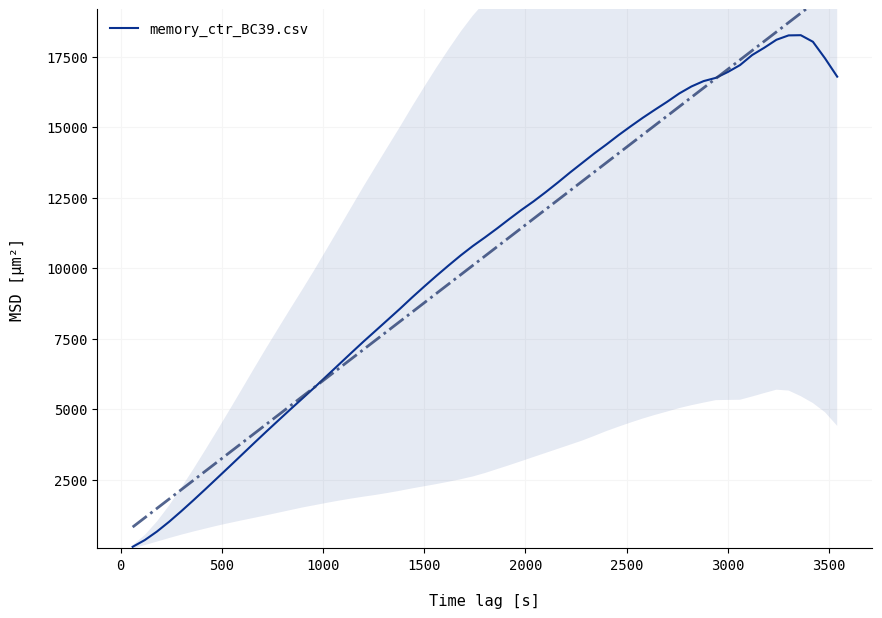

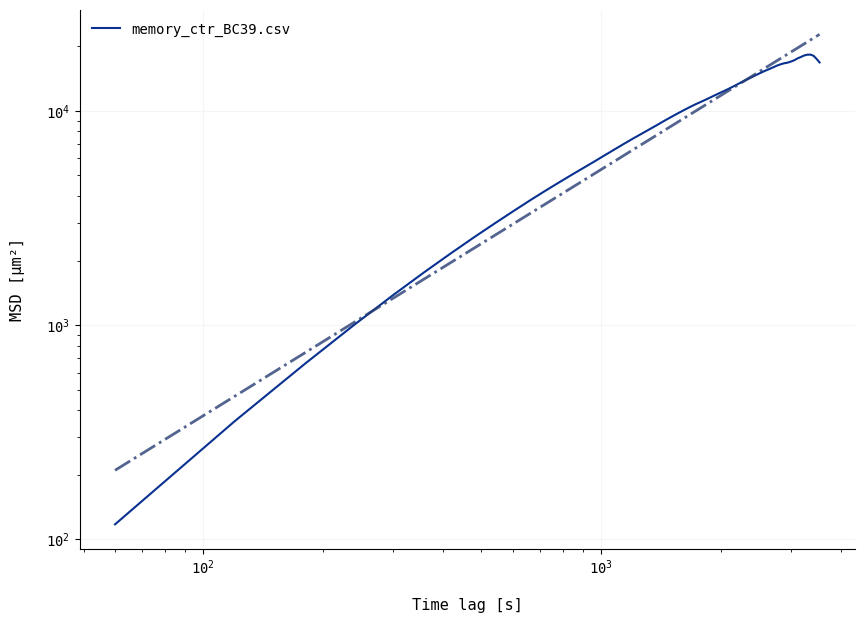

In [16]:
data_object.plot_msd(grid = True, linear_fit = True, band = 'sd')
data_object.plot_msd(grid = True, linear_fit = True, log = True)

In [17]:
list_ = [1, 2, 3]

list_ += [4]
print(list_)

[1, 2, 3, 4]


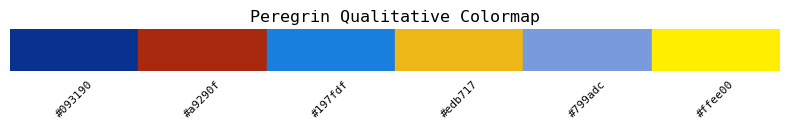

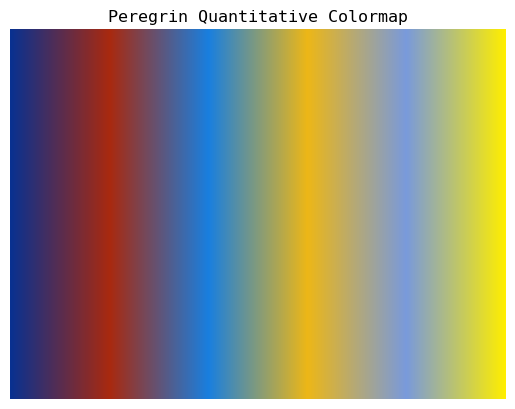

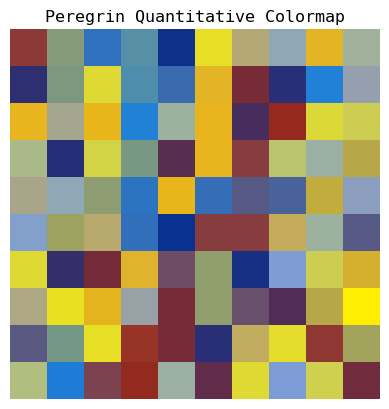

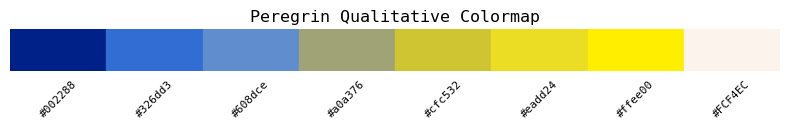

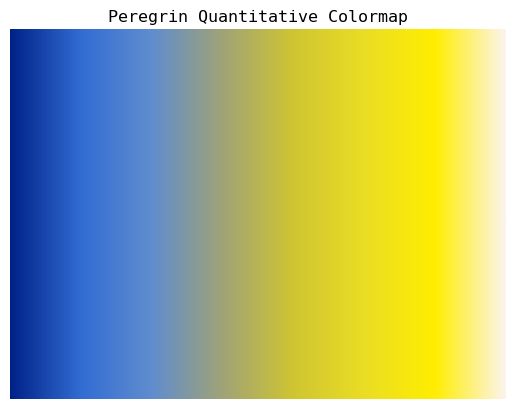

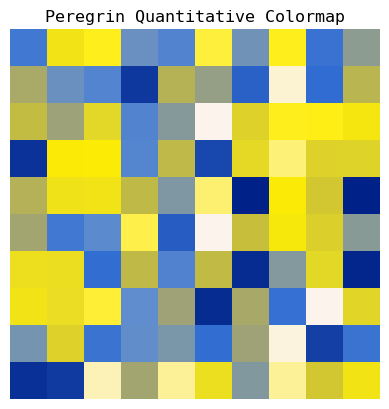

In [18]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

peregrin_cmap2 = ['#002288', "#326dd3", '#608dce', '#a0a376', '#cfc532', '#eadd24', '#ffee00', "#FCF4EC"]
peregrin_cmap1 = ['#093190', "#a9290f", '#197fdf', '#edb717', '#799adc',  '#ffee00']

def peregrin_cmap_func(peregrin_cmap):

    fig, ax = plt.subplots(figsize=(8, 1.5))
    n = len(peregrin_cmap)
    for i, color in enumerate(peregrin_cmap):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
        ax.text(i + 0.5, -0.15, color, ha='center', va='top', fontsize=8, rotation=45)

    ax.set_xlim(0, n)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title("Peregrin Qualitative Colormap")
    plt.tight_layout()
    plt.show()

    quantitative_cmap = mcolors.LinearSegmentedColormap.from_list("_peregrin", peregrin_cmap)
    plt.imshow(np.linspace(0, 1, 256).reshape(1, -1), aspect='auto', cmap=quantitative_cmap)
    plt.axis('off')
    plt.title("Peregrin Quantitative Colormap")
    plt.show()

    plt.imshow(np.array(np.repeat(np.random.rand(10, 10), 1, axis=0)), cmap=quantitative_cmap)
    plt.axis('off')
    plt.title("Peregrin Quantitative Colormap")
    plt.show()


for cmap in [peregrin_cmap1, peregrin_cmap2]:
    peregrin_cmap_func(cmap)